In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses, observableClasses
import datetime
import numpy as np
from tqdm import tqdm
from scipy.optimize import curve_fit
from scipy import stats
import pickle
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("style.mplstyle")

In [2]:
dataset = baseClasses.Data()

In [3]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 6, 15)) & (dataset.data.index < datetime.datetime(2024, 8, 1)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:05<00:00,  9.36sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 48/48 [00:00<00:00, 88.27sensor/s]
Initializing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00,  8.19sensor/s]


ERROR: Channel (TE0120) not found


Equalizing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00, 10.57sensor/s]


ERROR: Channel (TE0120) not found


Calibrating PIPE Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 12/12 [00:00<00:00, 105.41sensor/s]
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


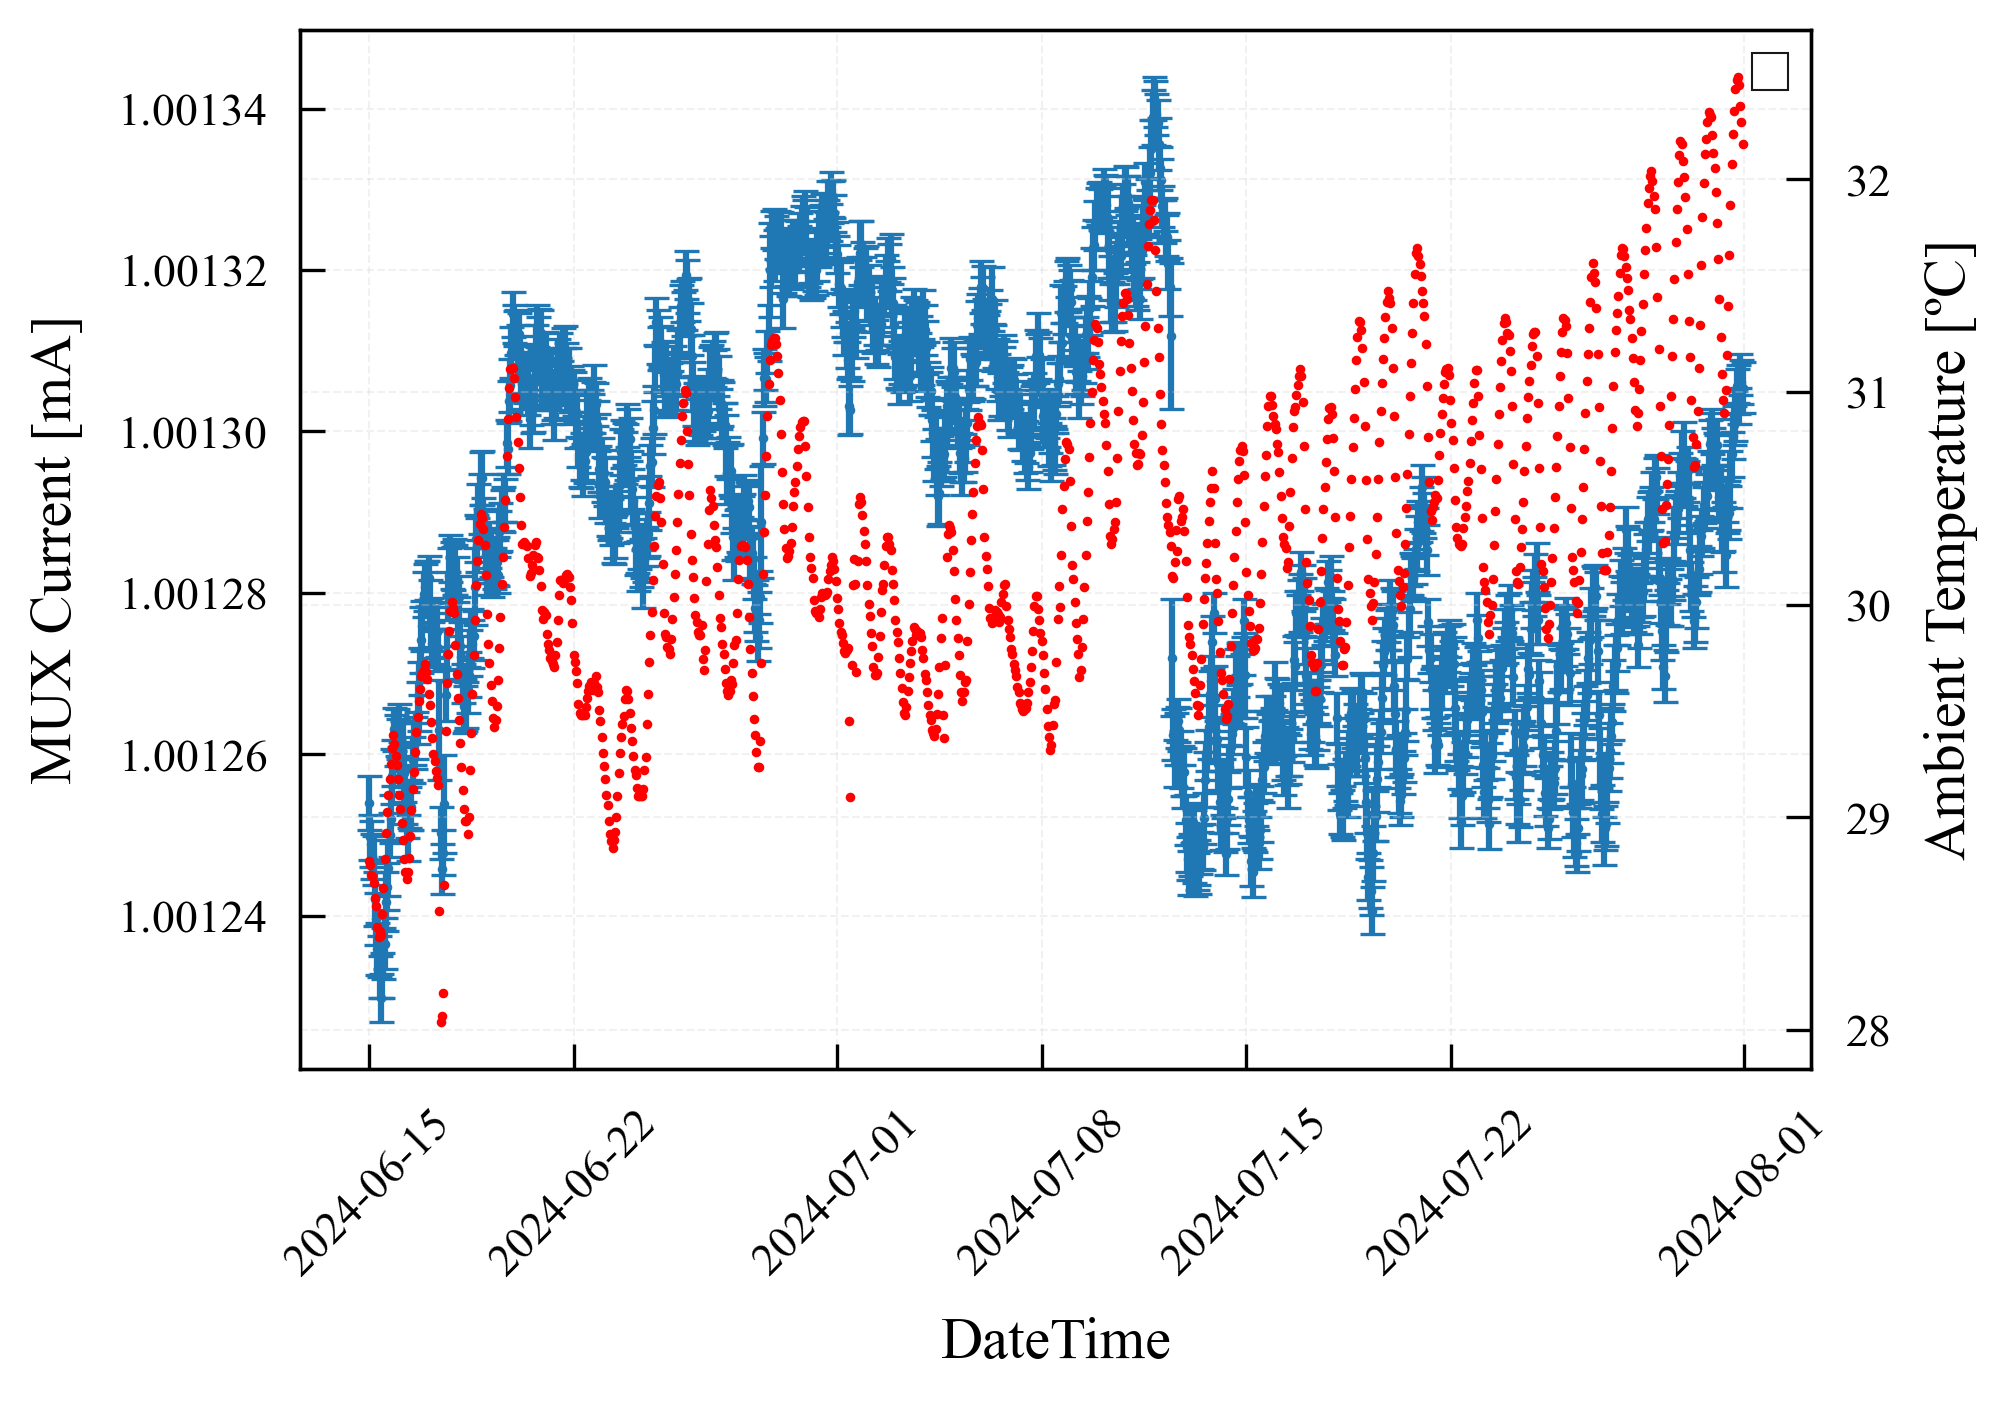

In [29]:
mux1 = muxClasses.MUX(dataset, boardNumber=1)
ambientT = sensorClasses.Sensor(dataset, id=1037)
ambientP = sensorClasses.Sensor(dataset, id=1038)
cryoP = sensorClasses.Sensor(dataset, id=1011)
system = systemClasses.System(dataset, name="TGRAD")
system.calibrate("SECOND_POFF_OCTOBER")
sensor = system.sensors[39607]
inletT = systemClasses.System(dataset, name="PIPE")
inletT.calibrate("SECOND_POFF_OCTOBER")
inlet = inletT.sensors[49319]


fig, axes = plt.subplots(1,1)
axes.errorbar(mux1.data.resample("1H").mean().index.values, mux1.data.resample("1H").mean().values, yerr=mux1.data.resample("1H").std().values, marker="o", markersize=1.5, linestyle="None")
axes.tick_params(axis='x', rotation=45)
axes.set_xlabel("DateTime")
axes.set_ylabel("MUX Current [mA]")

axes2 = axes.twinx()
axes2.plot(ambientT.data.resample("1H").mean().index.values, ambientT.data.resample("1H").mean().values, color="red", marker="o", markersize=1.5, linestyle="None")
axes2.set_ylabel("Ambient Temperature [ºC]")
# axes.set_ylim(0.2481, 0.2483)
axes2.legend()
# axes.set_xlim(datetime.datetime(2024, 4, 30), datetime.datetime(2024, 12, 3))



In [12]:
bulk = observableClasses.Bulk(dataset)

Configuration-aware bulk temperature setup:

Configuration: baseline
Time period: 2024-06-15 00:01:00 to 2024-07-31 23:59:00

  System: TGRAD
  Boards 1-4: 1.0, 2.0
  Channels: TE0001, TE0002, TE0003, TE0004, TE0005, TE0006, TE0007, TE0008, TE0009, TE0010 ... (+38 more)

  System: HAWAI
  Boards 1-4: 3.0
  Channels: TE0049, TE0050, TE0051, TE0052, TE0053, TE0054, TE0055, TE0056, TE0057, TE0058 ... (+14 more)

  System: PP
  Boards 1-4: 4.0
  Channels: TE0073, TE0074

  System: PRM
  Boards 1-4: 4.0
  Channels: TE0079, TE0080, TE0081, TE0082, TE0083, TE0084

  System: PIPE
  Boards 1-4: 4.0
  Channels: TE0085, TE0086, TE0087, TE0088, TE0089, TE0090, TE0091, TE0092, TE0093, TE0094 ... (+2 more)


Initializing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00,  9.68sensor/s]

ERROR: Channel (TE0120) not found


In [14]:
bulk.define()


Processing configurations for bulk temperature calculation...

Processing configuration: baseline


Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:05<00:00,  8.20sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 48/48 [00:00<00:00, 71.58sensor/s]


      Debug sensor 39666: name='TGRAD1', system='TGRAD', board=1.0, calibrated=True
      Debug sensor 39665: name='TGRAD2', system='TGRAD', board=1.0, calibrated=True
      Debug sensor 39664: name='TGRAD3', system='TGRAD', board=1.0, calibrated=True
      Debug sensor 39667: name='TGRAD4', system='TGRAD', board=1.0, calibrated=True
      Debug sensor 39661: name='TGRAD5', system='TGRAD', board=1.0, calibrated=True
    TGRAD: 48 total sensors
      High precision (boards 1-4, calibrated): 48
      Far from inlets (>1500mm): 36
      Far from CE (>1500mm): 36
      Below interface (Y<6100mm): 25
      Final qualifying sensors: 25


Equalizing HAWAI Sensors: 100%|██████████| 24/24 [00:01<00:00, 12.30sensor/s]
Calibrating HAWAI Sensors - Calibration Name: FIRST_POFF_PRECISION: 100%|██████████| 24/24 [00:00<00:00, 98.12sensor/s]


    HAWAI: 24 total sensors
      High precision (boards 1-4, calibrated): 24
      Far from inlets (>1500mm): 24
      Far from CE (>1500mm): 16
      Below interface (Y<6100mm): 8
      Final qualifying sensors: 8


...

ERROR: Channel (TE0120) not found


Equalizing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00,  9.86sensor/s]


ERROR: Channel (TE0120) not found


Calibrating PIPE Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 12/12 [00:00<00:00, 93.83sensor/s]


    PIPE: 12 total sensors
      High precision (boards 1-4, calibrated): 12
      Far from inlets (>1500mm): 4
      Far from CE (>1500mm): 4
      Below interface (Y<6100mm): 4
      Final qualifying sensors: 4
Configuration baseline: 45 sensors included from systems ['TGRAD', 'HAWAI', 'PP', 'PRM', 'PIPE']


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(19889.0, 19905.0)

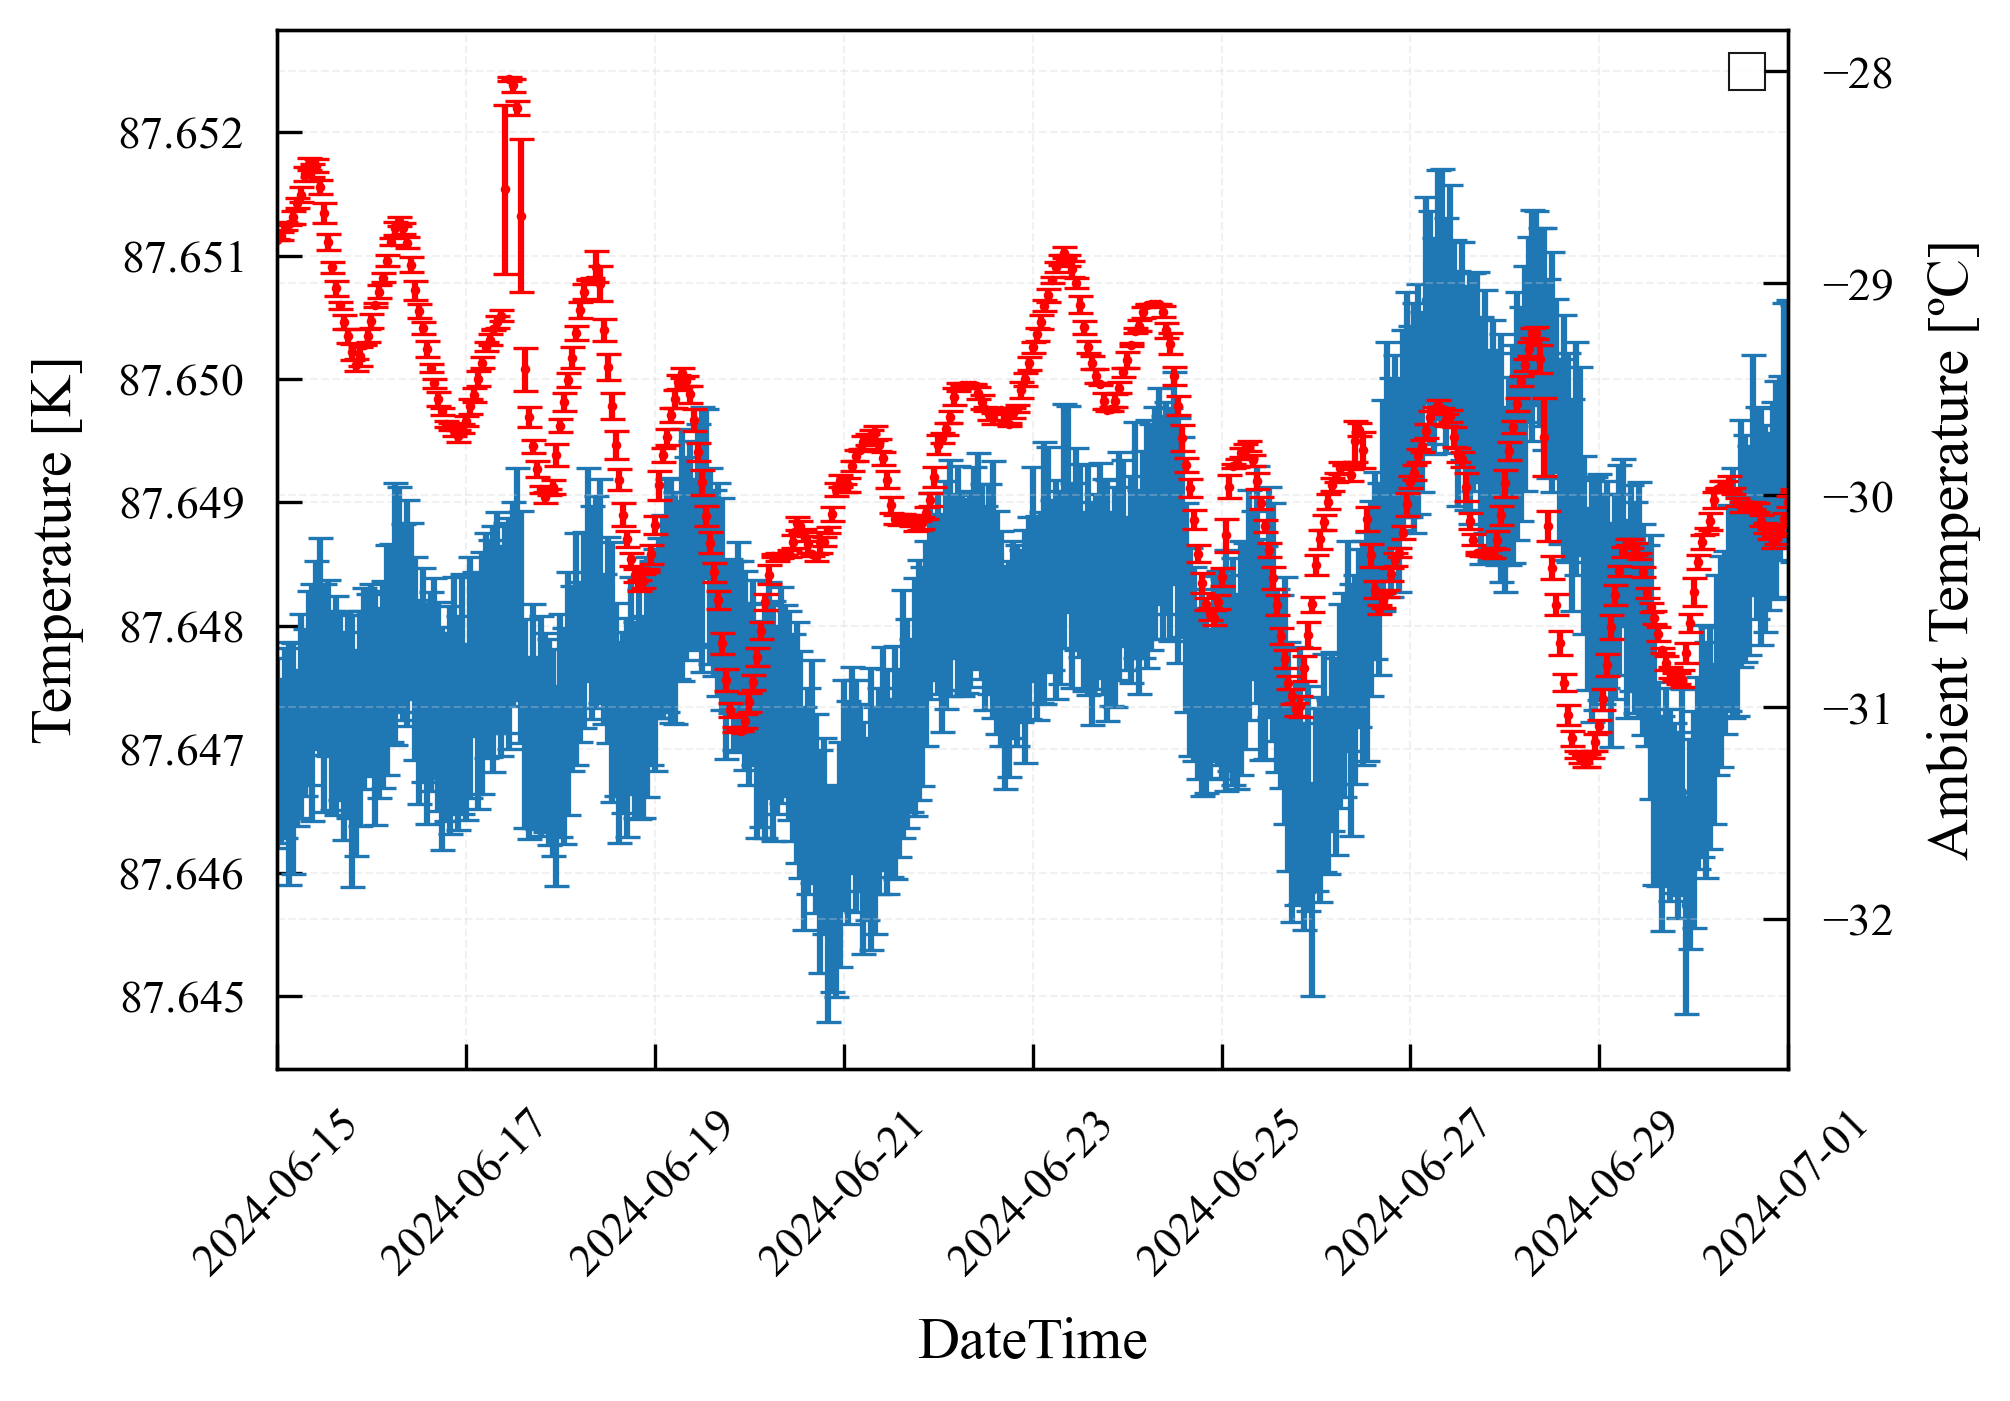

In [25]:
fig, axes = plt.subplots(1,1)
axes.errorbar(sensor.data.resample("1H").mean().index.values, sensor.data.resample("1H").mean().values, yerr=sensor.data.resample("1H").std().values, marker="o", markersize=1.5, linestyle="None")
axes.tick_params(axis='x', rotation=45)
axes.set_xlabel("DateTime")
axes.set_ylabel("Temperature [K]")

axes2 = axes.twinx()
axes2.errorbar(ambientT.data.resample("1H").mean().index.values, -ambientT.data.resample("1H").mean().values, yerr=ambientT.data.resample("1H").std().values, color="red", marker="o", markersize=1.5, linestyle="None")
axes2.set_ylabel("Ambient Temperature [ºC]")
# axes.set_ylim(0.2481, 0.2483)
axes2.legend()
axes.set_xlim(datetime.datetime(2024, 6, 15), datetime.datetime(2024, 7, 1))

In [18]:
print(bulk.bulk["baseline"]["data"])

                          temp       err
Unnamed: 0                              
2024-06-15 00:01:00        NaN       NaN
2024-06-15 00:02:00        NaN       NaN
2024-06-15 00:03:00  87.651695  0.005822
2024-06-15 00:04:00        NaN       NaN
2024-06-15 00:05:00        NaN       NaN
...                        ...       ...
2024-07-31 23:55:00  87.655893  0.006491
2024-07-31 23:56:00  87.655703  0.006228
2024-07-31 23:57:00  87.655487  0.005816
2024-07-31 23:58:00  87.655433  0.006127
2024-07-31 23:59:00  87.655512  0.005975

[67679 rows x 2 columns]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(19889.0, 19896.0)

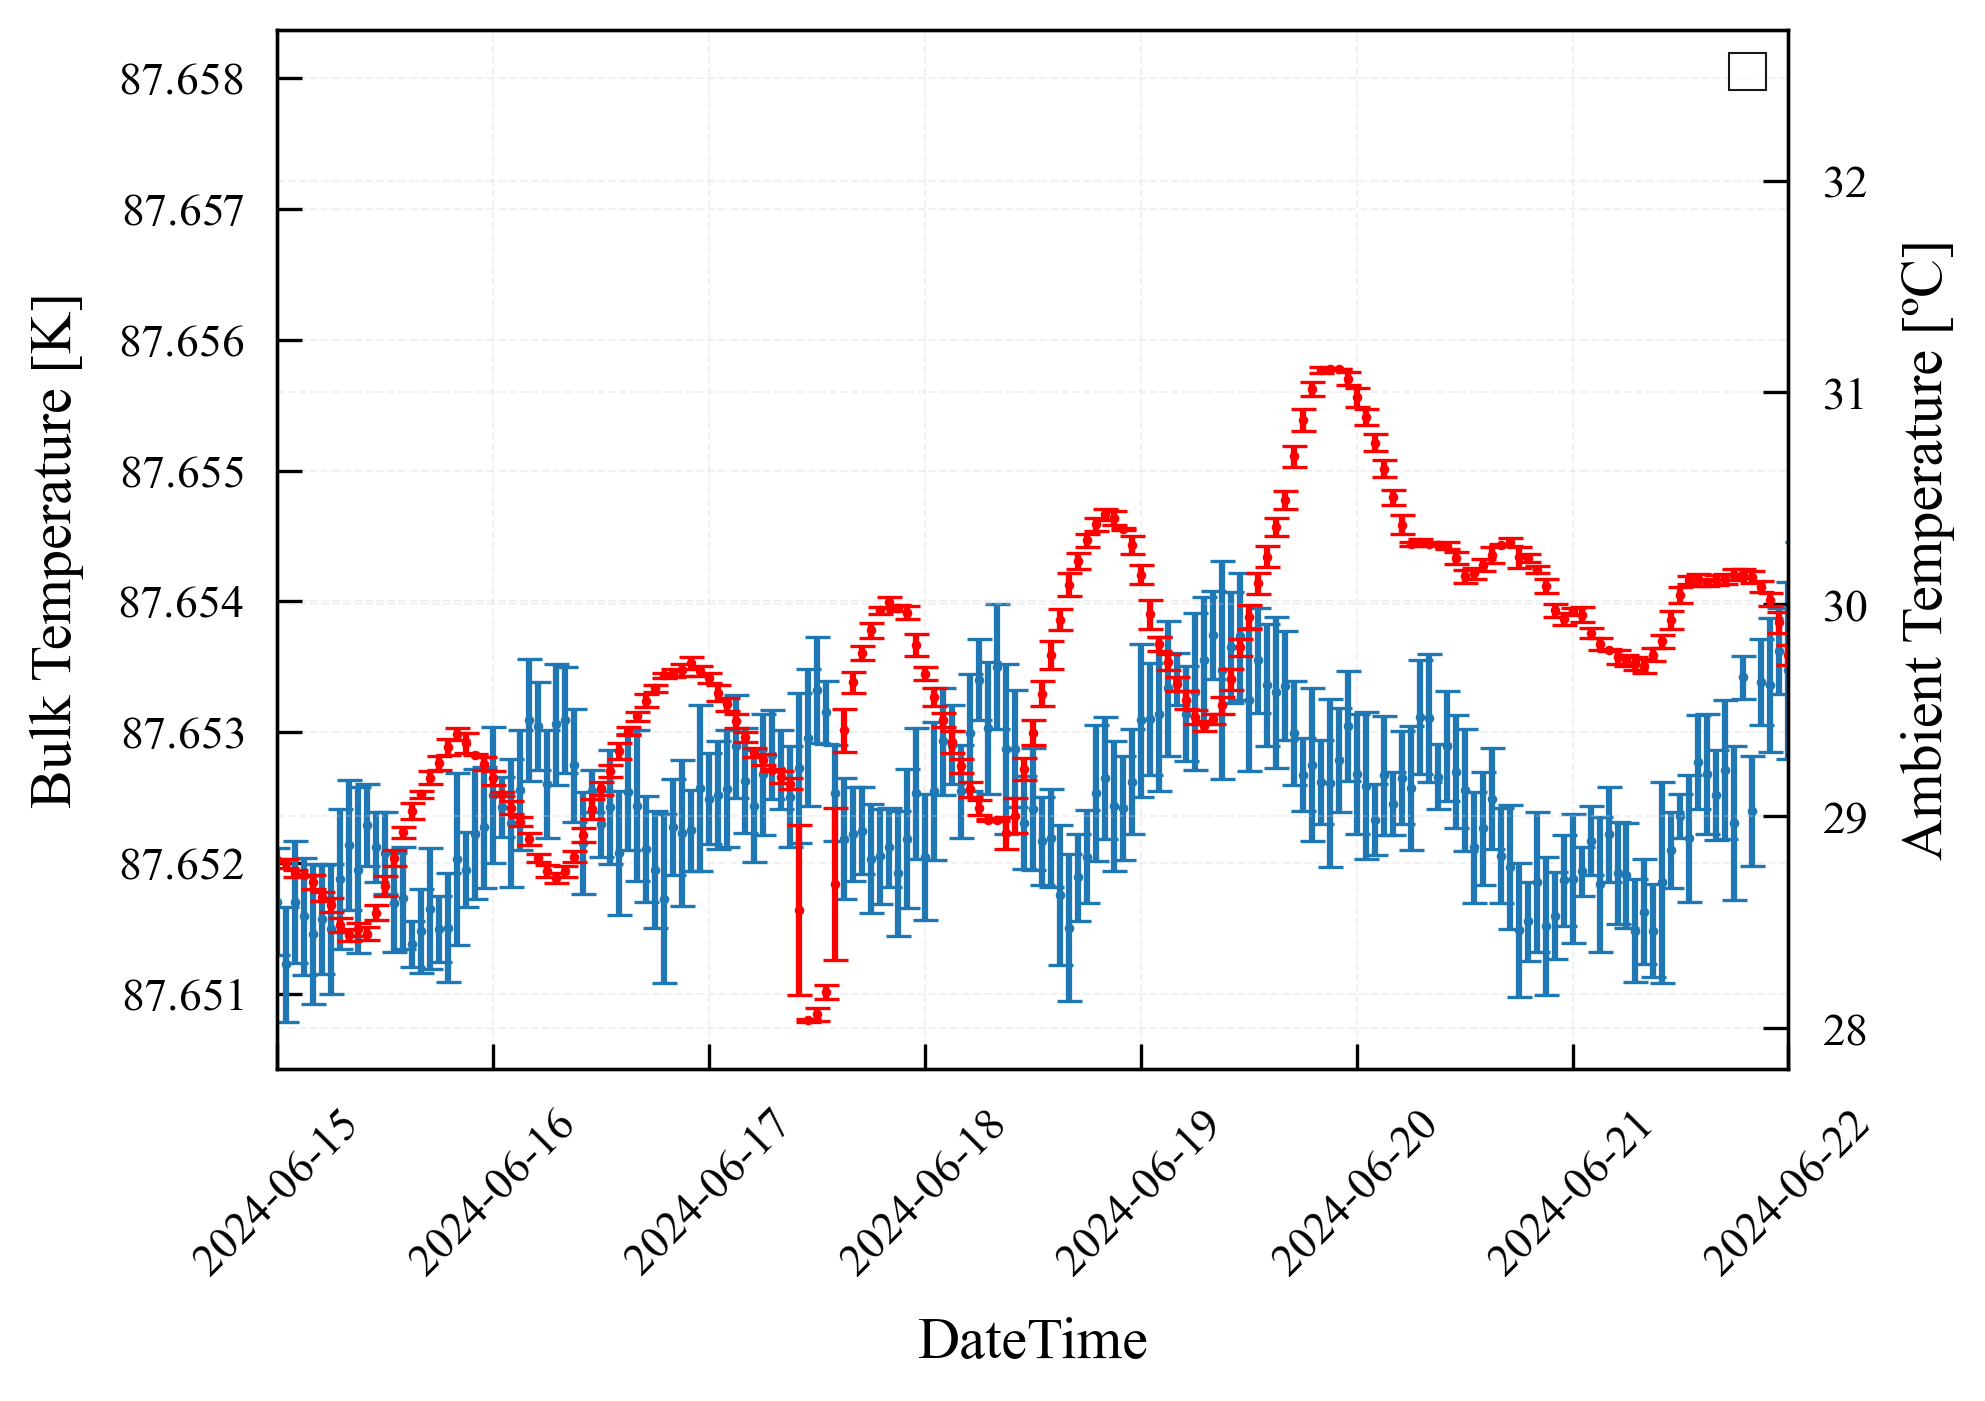

In [32]:
fig, axes = plt.subplots(1,1)
axes.errorbar(bulk.bulk["baseline"]["data"].resample("1H").mean().index.values, bulk.bulk["baseline"]["data"]["temp"].resample("1H").mean().values, yerr=bulk.bulk["baseline"]["data"]["temp"].resample("1H").std().values, marker="o", markersize=1.5, linestyle="None")
axes.tick_params(axis='x', rotation=45)
axes.set_xlabel("DateTime")
axes.set_ylabel("Bulk Temperature [K]")
axes2 = axes.twinx()
axes2.errorbar(ambientT.data.resample("1H").mean().index.values, ambientT.data.resample("1H").mean().values, yerr=ambientT.data.resample("1H").std().values, color="red", marker="o", markersize=1.5, linestyle="None")
axes2.set_ylabel("Ambient Temperature [ºC]")
# axes.set_ylim(0.2481, 0.2483)
axes2.legend()
axes.set_xlim(datetime.datetime(2024, 6, 15), datetime.datetime(2024, 6, 22))



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(19889.0, 19896.0)

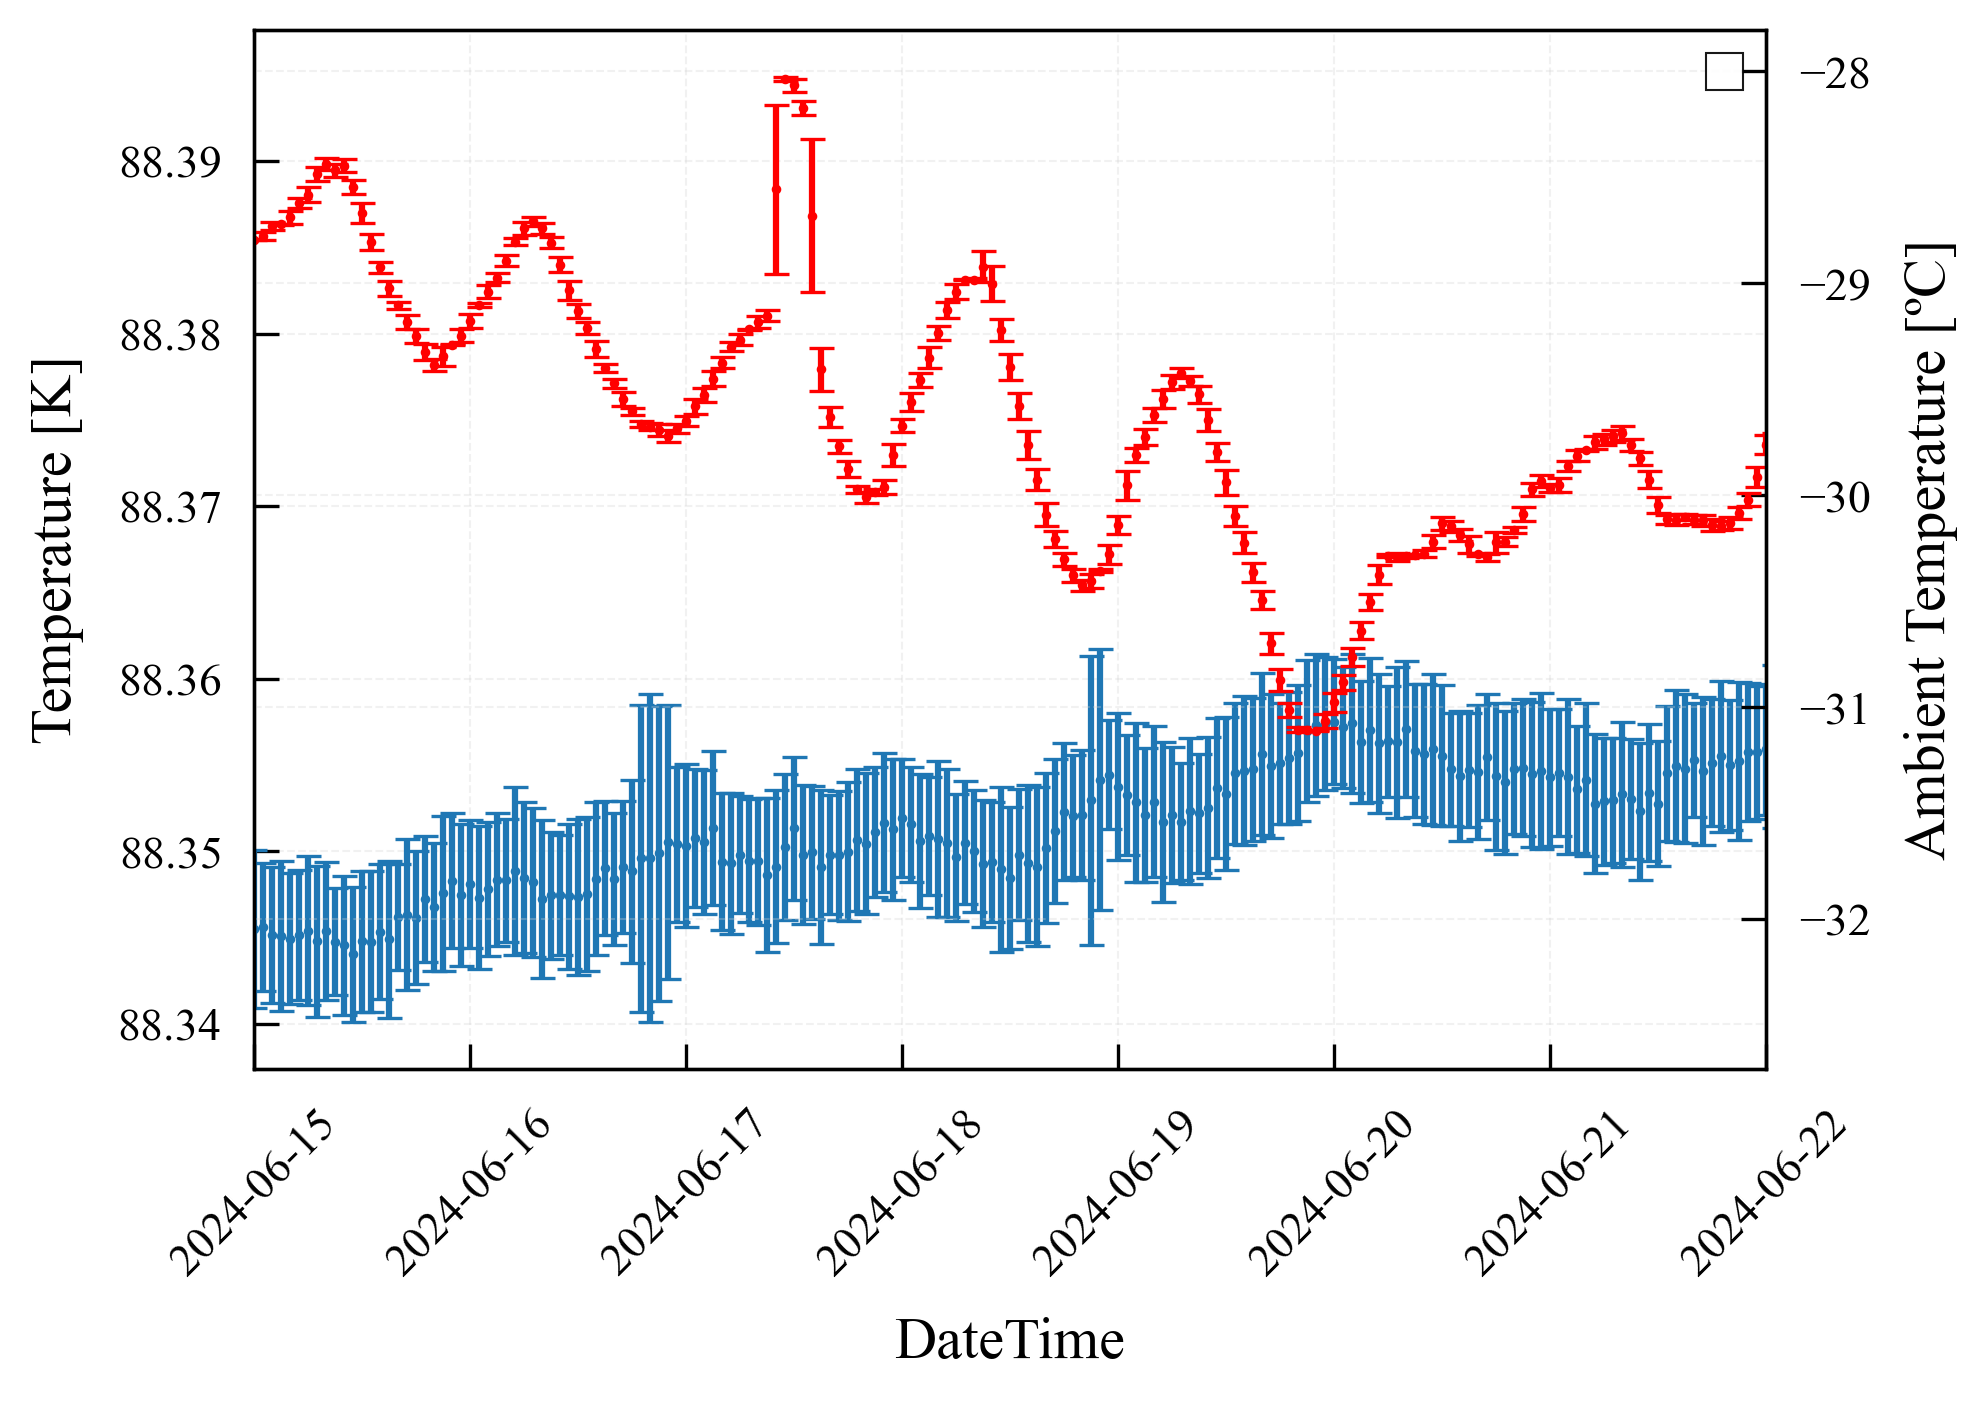

In [33]:
fig, axes = plt.subplots(1,1)
axes.errorbar(inlet.data.resample("1H").mean().index.values, inlet.data.resample("1H").mean().values, yerr=inlet.data.resample("1H").std().values, marker="o", markersize=1.5, linestyle="None")
axes.tick_params(axis='x', rotation=45)
axes.set_xlabel("DateTime")
axes.set_ylabel("Temperature [K]")

axes2 = axes.twinx()
axes2.errorbar(ambientT.data.resample("1H").mean().index.values, -ambientT.data.resample("1H").mean().values, yerr=ambientT.data.resample("1H").std().values, color="red", marker="o", markersize=1.5, linestyle="None")
axes2.set_ylabel("Ambient Temperature [ºC]")
# axes.set_ylim(0.2481, 0.2483)
axes2.legend()
axes.set_xlim(datetime.datetime(2024, 6, 15), datetime.datetime(2024, 6, 22))

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(19889.0, 19896.0)

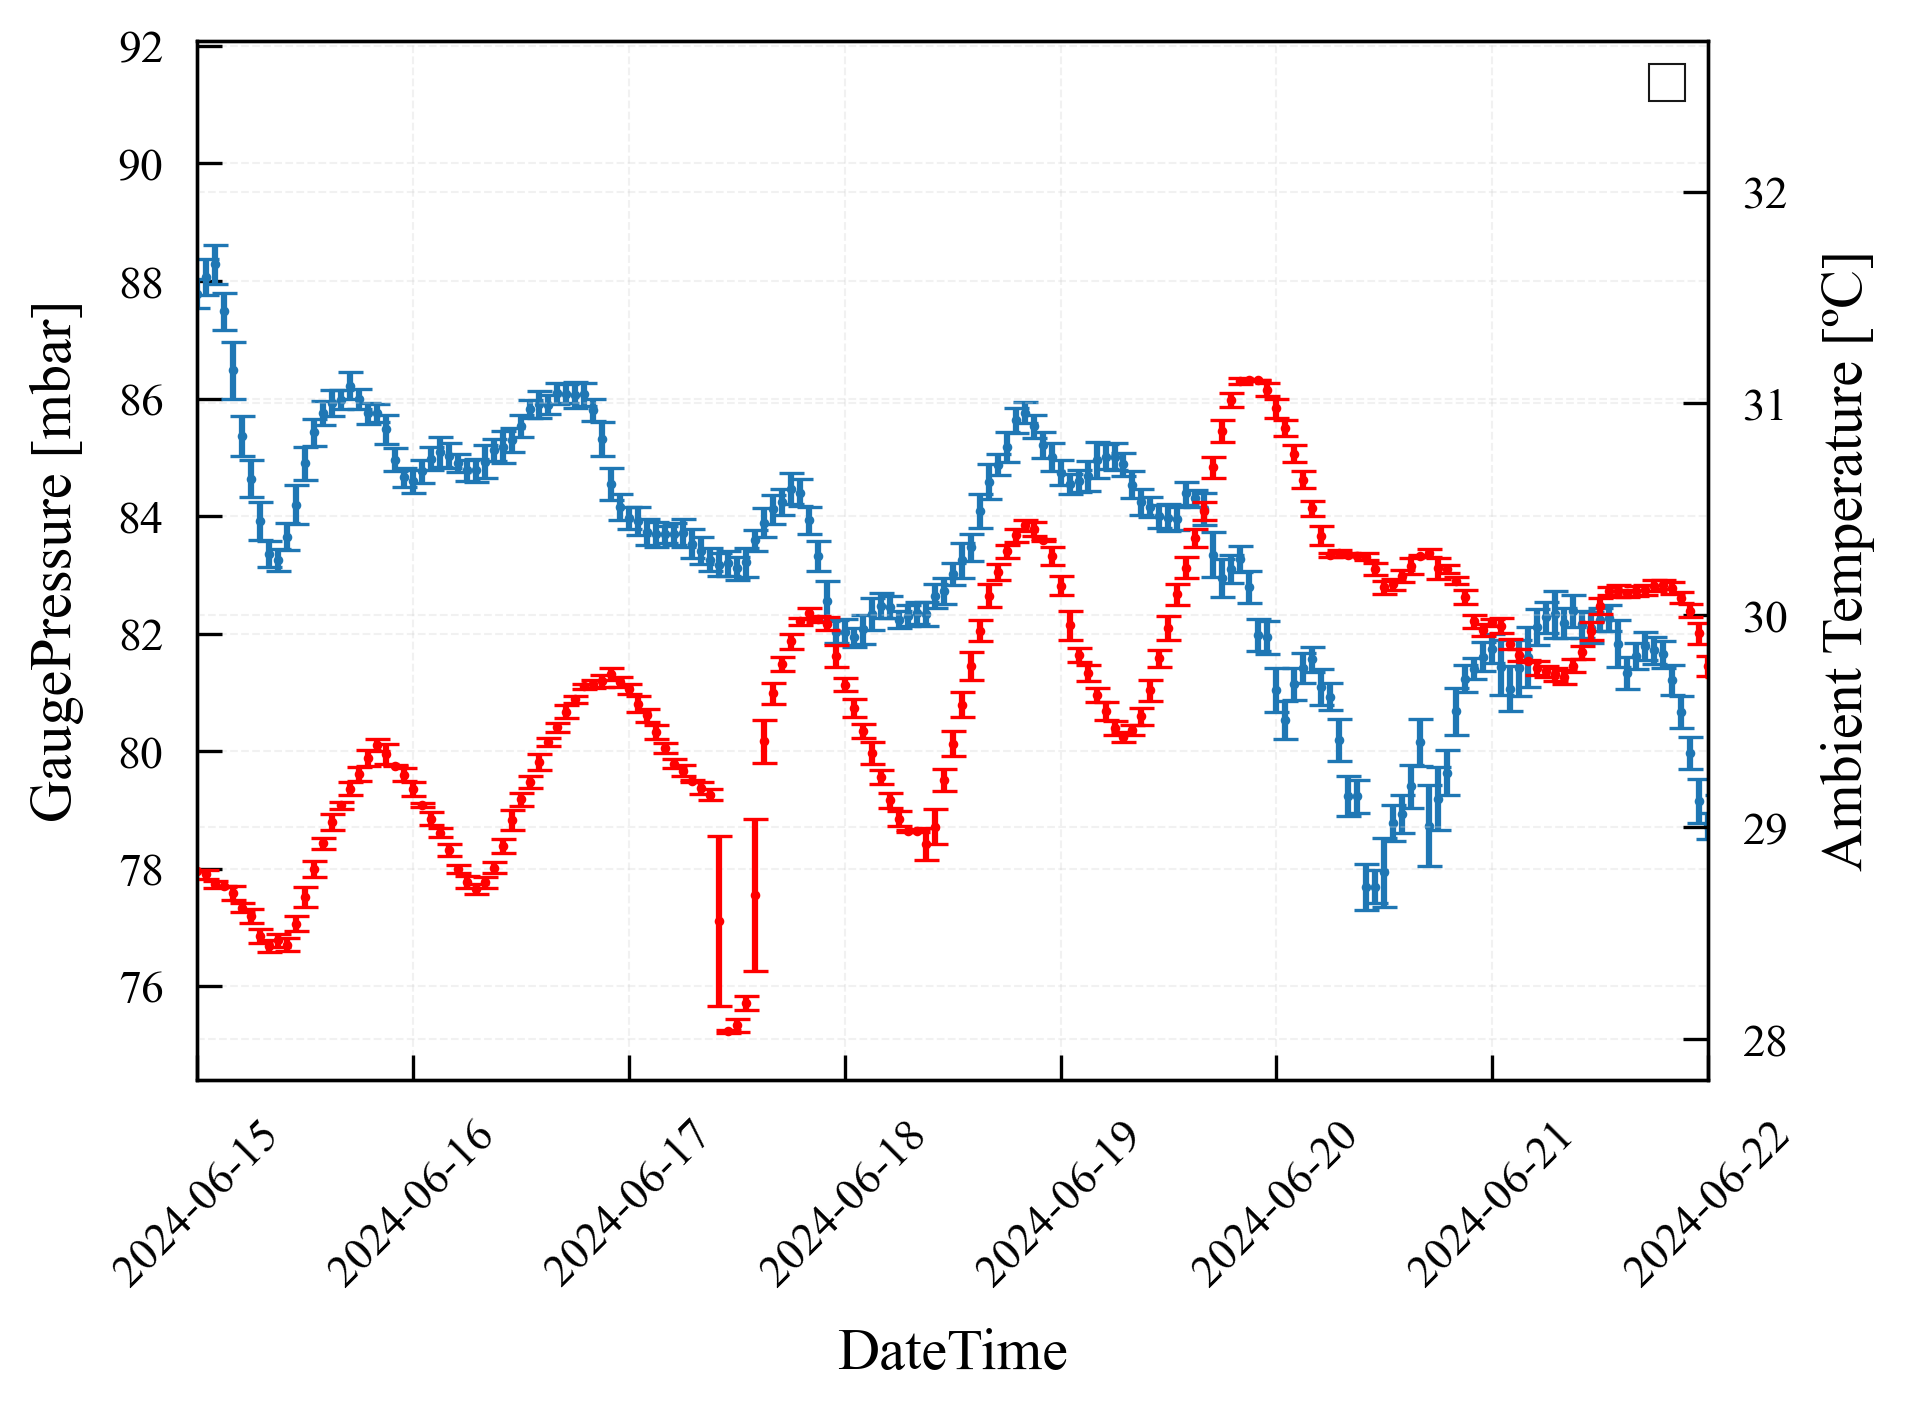

In [41]:
cryoP = sensorClasses.Sensor(dataset, id=1015)
fig, axes = plt.subplots(1,1)
axes.errorbar(cryoP.data.resample("1H").mean().index.values, cryoP.data.resample("1H").mean().values, yerr=cryoP.data.resample("1H").std().values, marker="o", markersize=1.5, linestyle="None")
axes.tick_params(axis='x', rotation=45)
axes.set_xlabel("DateTime")
axes.set_ylabel("GaugePressure [mbar]")

axes2 = axes.twinx()
axes2.errorbar(ambientT.data.resample("1H").mean().index.values, ambientT.data.resample("1H").mean().values, yerr=ambientT.data.resample("1H").std().values, color="red", marker="o", markersize=1.5, linestyle="None")
axes2.set_ylabel("Ambient Temperature [ºC]")
# axes.set_ylim(0.2481, 0.2483)
axes2.legend()
axes.set_xlim(datetime.datetime(2024, 6, 15), datetime.datetime(2024, 6, 22))